In [524]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Numpy untuk manipulasi array numerik, matplotlib untuk visualisasi dan menampilkan gambar, serta cv2 (OpenCV) untuk pemrosesan citra seperti baca, edit, dan deteksi objek. Ketiganya menjadi dasar umum dalam proyek pengolahan gambar.

Kode di bawah ini untuk membaca file gambar robby_negatif.jpg dari folder assets menggunakan plt.imread() dan menyimpannya ke variabel robby. Selanjutnya, plt.imshow(robby) menampilkan gambar tersebut, plt.axis('off') menghilangkan sumbu koordinat, dan plt.show() menampilkan gambar ke layar.

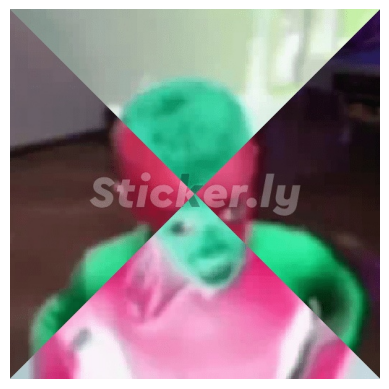

In [525]:
robby = plt.imread('assets/robby_negatif.jpg')
plt.imshow(robby)
plt.axis('off')
plt.show()

Kode di bawah ini memotong gambar berbentuk segitiga (bagian tengah meruncing ke bawah), lalu mengubahnya menjadi negatif (255 - image) dan karena gambar awal sudah negatif (robby_negatif.jpg), hasil akhirnya kembali ke warna normal. Fungsi segitiga() membatasi area pemrosesan, ubah_ke_normal()menginversi warna, dan output menampilkan potongan segitiga dengan warna asli.

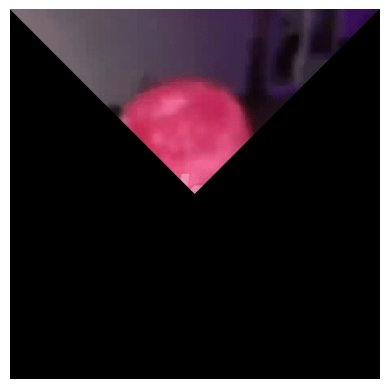

In [526]:
def segitiga(image, tinggi, lebar):

    hasil = np.zeros_like(image)

    for y in range(tinggi):

        kiri = y
        kanan = lebar - y

        hasil[y:y+1, kiri:kanan] = image[y:y+1, kiri:kanan]

    return hasil


def ubah_ke_normal(image, tinggi, lebar):

    hasil = np.zeros_like(image)

    for y in range(tinggi):

        kiri = y
        kanan = lebar - y

        hasil[y:y+1, kiri:kanan] = 255 - image[y:y+1, kiri:kanan]

    return hasil


tinggi = 256
lebar = 511

segitiga1 = segitiga(robby, tinggi, lebar)

normal1 = ubah_ke_normal(segitiga1, tinggi, lebar)

plt.imshow(normal1)
plt.axis('off')
plt.show()

Kode di bawah ini untuk fungsi fungsi_empat_R, untuk memutar gambar 90°, 180°, atau 270°. Nilai sudut diambil dari parameter val lalu dimodulus 360. Fungsi membuat array kosong baru, lalu memetakan ulang piksel secara manual: 90° memindahkan (i,j) ke (j, h-1-i), 180° ke (h-1-i, w-1-j), dan 270° ke (w-1-j, i). Jika sudut 0 atau tidak dikenali, gambar asli dikembalikan. Pada bagian akhir, fungsi dipanggil dengan sudut 180° pada gambar robby, hasilnya ditampilkan sebagai gambar terbalik 180 derajat.

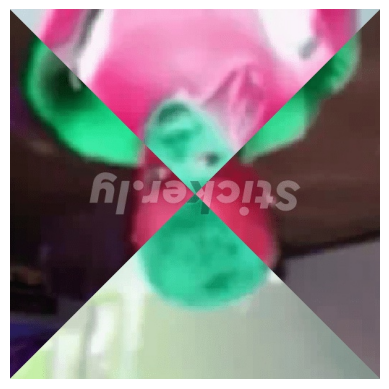

In [527]:
def fungsi_empat_R(image, val):

    h, w, c = image.shape
    val = int(val) % 360

    if val == 0:
        return image

    elif val == 90:

        rot = np.zeros((w, h, c), dtype=image.dtype)

        for i in range(h):
            for j in range(w):
                rot[j, h - 1 - i] = image[i, j]

        return rot

    elif val == 180:

        rot = np.zeros_like(image, dtype=image.dtype)

        for i in range(h):
            for j in range(w):
                rot[h - 1 - i, w - 1 - j] = image[i, j]

        return rot

    elif val == 270:

        rot = np.zeros((w, h, c), dtype=image.dtype)

        for i in range(h):
            for j in range(w):
                rot[w - 1 - j, i] = image[i, j]

        return rot

    return image


rotasi_satu = fungsi_empat_R(robby, 180)

plt.imshow(rotasi_satu)
plt.axis('off')
plt.show()

Kode di bawah ini mengambil hasil rotasi 180 derajat sebelumnya (rotasi_satu), lalu memotongnya dengan bentuk segitiga berukuran 512×512 menggunakan fungsi segitiga(). Hasil potongan tersebut kemudian diubah menjadi citra normal dengan ubah_ke_normal(), lalu diputar kembali 180 derajat dengan fungsi_empat_R(). Akhirnya adalah menampilkan potongan segitiga dari gambar yang sudah dirotasi, dengan warna kembali ke bentuk aslinya.

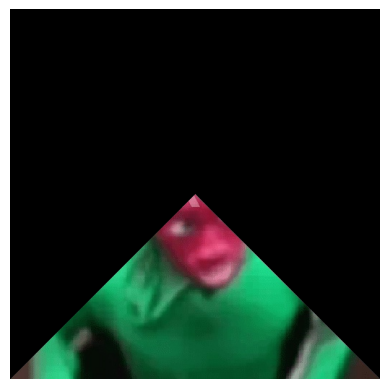

In [528]:
segitiga2 = segitiga(rotasi_satu, tinggi = 512, lebar = 512)
normal_dua = ubah_ke_normal(segitiga2, tinggi, lebar)
normal2 = fungsi_empat_R(normal_dua, 180)

plt.imshow(normal2)
plt.axis('off')
plt.show()

Kode di bawah ini untuk memutar gambar robby sebesar 90° (rotasi_dua), lalu memotongnya membentuk segitiga dengan fungsi segitiga(). Hasil potongan tersebut kemudian diputar lagi sebesar 270° menggunakan fungsi_empat_R(). Karena 90° + 270° = 360°, efek rotasi bersihnya adalah kembali ke orientasi semula, sehingga gambar akhir menampilkan potongan segitiga dari robby tanpa perubahan arah.

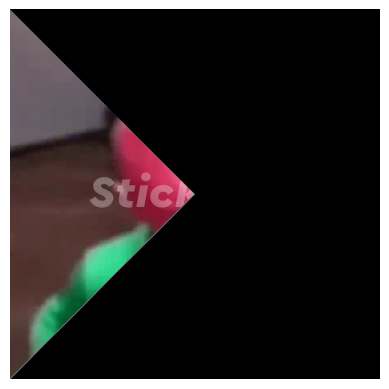

In [529]:
rotasi_dua = fungsi_empat_R(robby, 90)
segitiga3 = segitiga(rotasi_dua, tinggi, lebar)
normal3 = fungsi_empat_R(segitiga3, 270)

plt.imshow(normal3)
plt.axis('off')
plt.show()

Kode di bawah ini untuk memutar gambar robby sejauh 270° (rotasi_tiga), lalu memotongnya membentuk segitiga dengan fungsi segitiga(). Hasil potongan kemudian diputar lagi sejauh 90° menggunakan fungsi_empat_R(). Karena 270° + 90° = 360°, orientasi akhir gambar kembali seperti semula.

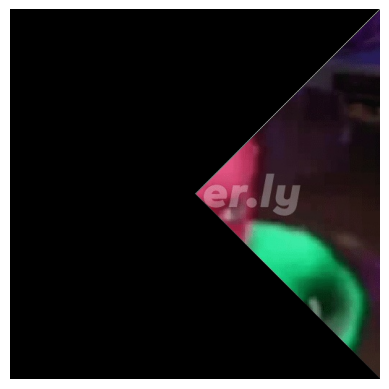

In [530]:
rotasi_tiga = fungsi_empat_R(robby, 270)
segitiga4 = segitiga(rotasi_tiga, tinggi, lebar)
normal4 = fungsi_empat_R(segitiga4, 90)

plt.imshow(normal4)
plt.axis('off')
plt.show()

Kode di bawah ini untuk fungsi merge_segitiga yaitu menggabungkan beberapa gambar dengan aturan setiap piksel pada kanvas akan diisi dari gambar mana pun yang nilai pikselnya lebih dari 0. Fungsi membuat kanvas kosong sesuai ukuran gambar pertama, lalu memindai setiap piksel dari setiap citra dalam daftar. Jika ditemukan nilai positif, kanvas akan menimpa piksel tersebut. Hasilnya, keempat potongan segitiga dari normal1, normal2, normal3, normal4 digabung menjadi satu gambar utuh (gabungan) dan ditampilkan.

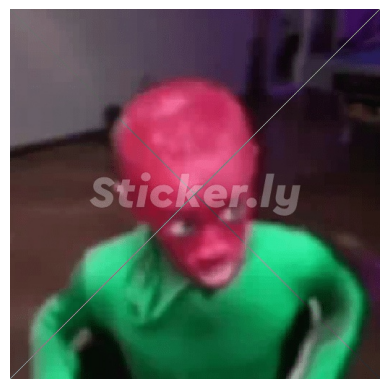

In [531]:
def merge_segitiga(citra_list):
    kanvas = np.zeros_like(citra_list[0])
    for citra in citra_list:
        for i in range(citra.shape[0]):
            for j in range(citra.shape[1]):
                if np.any(citra[i, j] > 0):
                    kanvas[i, j] = citra[i, j]
    return kanvas

gabungan = merge_segitiga([normal1, normal2, normal3, normal4])

plt.imshow(gabungan)
plt.axis('off')
plt.show()

Kode di bawah ini mengonversi gambar gabungan ke rentang 0-255, lalu melakukan ekualisasi histogram manual per kanal warna (menghitung histogram, CDF, dan memetakan ulang piksel untuk meratakan distribusi intensitas), kemudian hasilnya diinversi dengan (255 - hasil_ekualisasi). Gambar sebelum dan sesudah ditampilkan berdampingan, di mana ekualisasi bertujuan meningkatkan kontras, sementara inversi mengembalikan tampilan ke mode negatif.

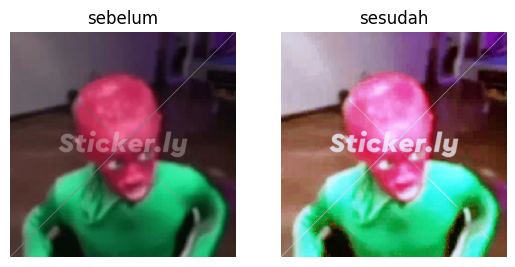

In [532]:
gabungan2 = (gabungan * 255).astype(np.uint8)

def ekualisasi(citra):

    height, width, channel = citra.shape

    hasil = np.zeros_like(citra, dtype=np.uint8)

    for c in range(channel):

        hist = np.zeros(256, dtype=int)

        for i in range(height):
            for j in range(width):

                val = citra[i][j][c]
                hist[val] += 1


        cdf = np.zeros(256, dtype=int)
        cdf[0] = hist[0]

        for i in range(1, 256):

            cdf[i] = cdf[i-1] + hist[i]


        cdf_normal = np.round(
            cdf * 255 / (height * width)
        ).astype(np.uint8)

        for i in range(height):
            for j in range(width):

                pixel_value = citra[i][j][c]

                hasil[i][j][c] = cdf_normal[pixel_value]

    return hasil


hasil_ekualisasi = ekualisasi(gabungan2)
hasil_ekualisasi2 = 255 - hasil_ekualisasi

plt.subplot(1,2,1)
plt.imshow(gabungan)
plt.title("sebelum")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hasil_ekualisasi2)
plt.title("sesudah")
plt.axis('off')

plt.show()

Kode di bawah ini mengekstrak masing-masing kanal warna (R, G, B) dari gambar gabungan dan hasil_ekualisasi2 ke dalam bentuk list dua dimensi, lalu menghitung histogram setiap kanal dengan fungsi buat_hist(), yaitu asumsinya menghitung frekuensi kemunculan nilai 0-255. Histogram dinormalisasi dengan membagi total piksel (total = tinggi × lebar) untuk mendapatkan probabilitas per intensitas. Hasilnya ditampilkan dalam dua subplot vertikal. 

Perbandingan ini memvisualisasikan perbedaan distribusi intensitas, sebelum proses cenderung tidak merata, sedangkan setelah proses (ekualisasi + inversi) distribusinya lebih menyebar atau merata.

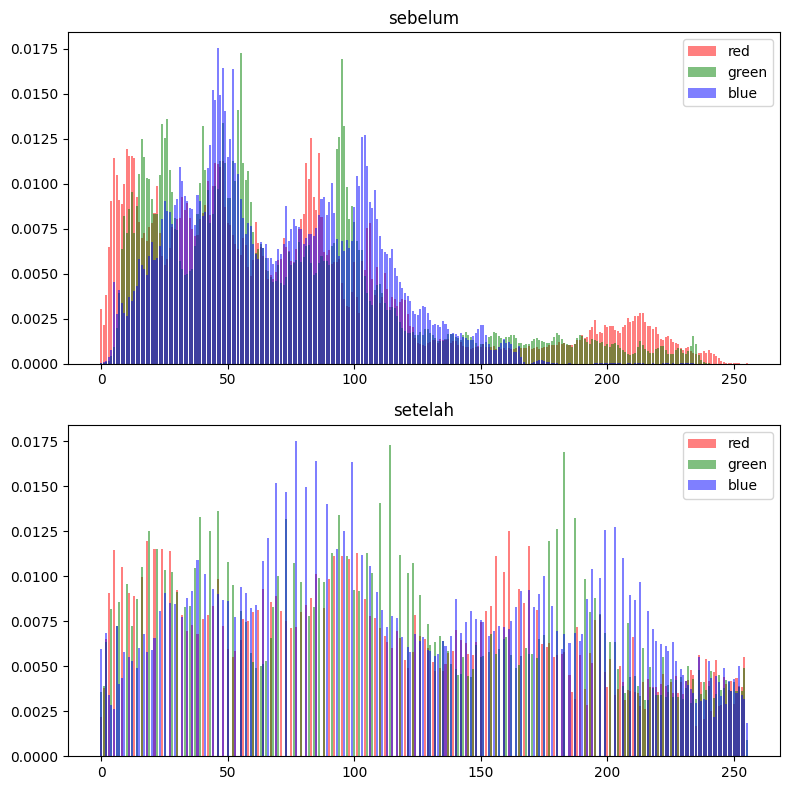

In [533]:
r_before = [[gabungan[i][j][0] for j in range(len(gabungan[0]))] for i in range(len(gabungan))]
g_before = [[gabungan[i][j][1] for j in range(len(gabungan[0]))] for i in range(len(gabungan))]
b_before = [[gabungan[i][j][2] for j in range(len(gabungan[0]))] for i in range(len(gabungan))]

r_after = [[hasil_ekualisasi2[i][j][0] for j in range(len(hasil_ekualisasi2[0]))] for i in range(len(hasil_ekualisasi2))]
g_after = [[hasil_ekualisasi2[i][j][1] for j in range(len(hasil_ekualisasi2[0]))] for i in range(len(hasil_ekualisasi2))]
b_after = [[hasil_ekualisasi2[i][j][2] for j in range(len(hasil_ekualisasi2[0]))] for i in range(len(hasil_ekualisasi2))]

total = len(gabungan) * len(gabungan[0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.set_title("sebelum")
ax1.bar(range(256), [v/total for v in buat_hist(r_before)], color='red',   width=0.8, alpha=0.5, label='red')
ax1.bar(range(256), [v/total for v in buat_hist(g_before)], color='green', width=0.8, alpha=0.5, label='green')
ax1.bar(range(256), [v/total for v in buat_hist(b_before)], color='blue',  width=0.8, alpha=0.5, label='blue')
ax1.legend()

ax2.set_title("setelah")
ax2.bar(range(256), [v/total for v in buat_hist(r_after)], color='red',   width=0.8, alpha=0.5, label='red')
ax2.bar(range(256), [v/total for v in buat_hist(g_after)], color='green', width=0.8, alpha=0.5, label='green')
ax2.bar(range(256), [v/total for v in buat_hist(b_after)], color='blue',  width=0.8, alpha=0.5, label='blue')
ax2.legend()

plt.tight_layout()
plt.show()

Kode di bawah ini mengonversi gambar gabungan dari RGB ke grayscale menggunakan cv2.cvtColor() dengan parameter cv2.COLOR_RGB2GRAY. Hasil konversi disimpan dalam variabel gabungan_gray, lalu ditampilkan dengan plt.imshow() menggunakan colormap 'gray' agar tampil dalam skala abu-abu.

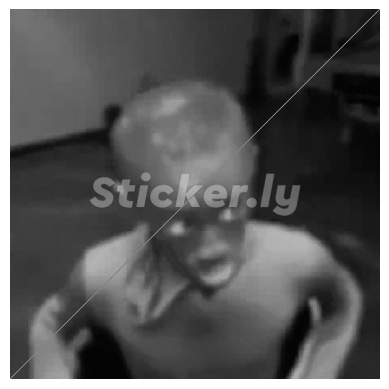

In [534]:
gabungan_gray = cv2.cvtColor(gabungan, cv2.COLOR_RGB2GRAY)
plt.imshow(gabungan_gray, cmap='gray')
plt.axis('off')
plt.show()

Kode di bawah ini membaca file gambar bahlul.jpg dari folder 'Assets' menggunakan plt.imread(), lalu mengonversinya ke grayscale dengan cv2.cvtColor(bahlul, cv2.COLOR_RGB2GRAY). Hasil konversi disimpan dalam variabel bahlul_gray dan ditampilkan menggunakan plt.imshow() dengan colormap 'gray' agar tampil dalam warna abu-abu.

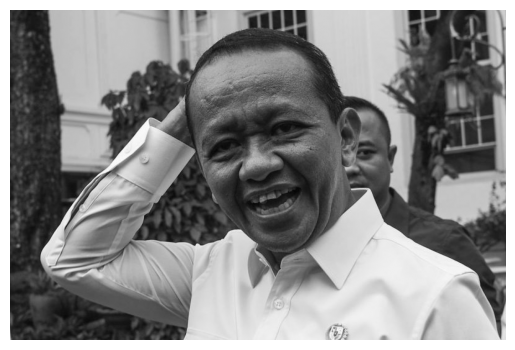

In [535]:
bahlul = plt.imread('Assets/bahlul.jpg')
bahlul_gray = cv2.cvtColor(bahlul, cv2.COLOR_RGB2GRAY)
plt.imshow(bahlul_gray, cmap='gray')
plt.axis('off')
plt.show()

Kode di bawah ini mendefinisikan fungsi spesifikasi histogram untuk menyamakan distribusi intensitas gambar asal (citra_asal) dengan gambar target (citra_target). Prosesnya adalah hitung histogram kedua gambar, hitung CDF masing-masing, normalisasi CDF ke rentang 0-1, lalu buat tabel pemetaan (map_hist) dengan mencari nilai CDF target yang paling mendekati setiap nilai CDF asal menggunakan selisih terkecil (np.argmin). Terakhir, terapkan pemetaan tersebut ke setiap piksel citra asal sehingga hasilnya memiliki karakteristik histogram seperti citra target. Fungsi ini berguna untuk menyeragamkan pencahayaan atau kontras antar dua gambar grayscale.

In [536]:
def spesifikasi(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
 
    height_asal, width_asal = citra_asal.shape
    for i in range(height_asal):
        for j in range(width_asal):
            pixel = citra_asal[i][j]
            hist_asal[pixel] += 1
 
    height_target, width_target = citra_target.shape
    for i in range(height_target):
        for j in range(width_target):
            pixel = citra_target[i][j]
            hist_target[pixel] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
    for i in range(256):
        selisih = np.abs(cdf_target - cdf_asal[i])
        j = np.argmin(selisih)
        map_hist[i] = j
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
    for i in range(height):
        for j in range(width):
            pixel = citra_asal[i][j]
            hasil[i][j] = map_hist[pixel]
 
    return hasil 

Kode di bawah ini memanggil fungsi spesifikasi(gabungan_gray, bahlul_gray) yang telah didefinisikan sebelumnya, di mana gabungan_gray sebagai citra asal dan bahlul_gray sebagai citra target. Proses ini memetakan distribusi intensitas gabungan_gray agar menyerupai histogram bahlul_gray (misalnya dari segi kontras atau pencahayaan). Hasilnya disimpan dalam spec_robby lalu ditampilkan dalam skala abu-abu. Tujuan akhirnya adalah membuat tampilan gabungan_gray memiliki karakteristik visual (seperti gelap-terang) yang mirip dengan gambar bahlul.jpg.

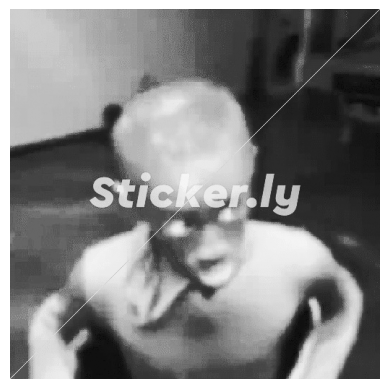

In [537]:
spec_robby = spesifikasi(gabungan_gray, bahlul_gray)
plt.imshow(spec_robby, cmap='gray')
plt.axis('off')
plt.show()

Kesimpulannya adalah seluruh kode mengimplementasikan pemotongan bentuk segitiga, operasi negatif dan rotasi 90°/180°/270°, penggabungan empat potongan menjadi satu kanvas, ekualisasi histogram untuk meningkatkan kontras, serta spesifikasi histogram yang memetakan distribusi intensitas gabungan_gray agar menyerupai bahlul_gray.